# **Análisis de resultados tras 100 simulaciones**

Este cuaderno tiene como objetivo analizar los resultados generados por el modelo `CardioModel`. Mediante simulaciones de Montecarlo (100 iteraciones), evaluaremos la evolución del colesterol LDL, el cumplimiento nutricional y la tasa de adherencia de los pacientes virtuales bajo dos intervenciones dietéticas distintas: la **Dieta Mediterránea** y la **Dieta Baja en Grasas**.

A continuación, se importan las librerías necesarias y se configuran las rutas para acceder a las variables y clases del modelo:

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
import seaborn as sns
import numpy as np
from tqdm import tqdm
import sys
import os

# Configuración de ruta para encontrar variables y modelo
sys.path.append(os.path.abspath('..'))
from model.cardioModel import CardioModel
from configuration import settings

<IPython.core.display.Javascript object>

Could not import SolaraViz. If you need it, install with 'pip install --pre mesa[viz]'


Dado que el modelo incluye variables estocásticas (ruido estadístico en la ingesta, probabilidad de abandono, etc.), los resultados de una única simulación no son estadísticamente robustos. 

Para solucionar esto, aplicamos el método **Montecarlo**, ejecutando el modelo múltiples veces para obtener una muestra representativa del comportamiento poblacional. Definimos entonces un total de 100 simulaciones independientes: cada iteración instanciará 212 pacientes completamente nuevos que irán registrando datos de ingesta y de evolución de biomarcadores a lo largo de 12 semanas. Finalmente, se concatenarán todos los datos en un único *DataFrame* que contendrá el historial completo de los 21200 pacientes simulados.

In [2]:
# 1. Configuración de la simulación (100 iteraciones)
NUM_SIMULACIONES = 1000
SEMANAS = 12

# Lista vacía para almacenar resultados de cada simulación
resultados = []

# Mostrar datos con solo 2 decimales
pd.options.display.float_format = '{:.2f}'.format

# 2. Bucle principal de simulaciones
print(f"Iniciando {NUM_SIMULACIONES} simulaciones independientes de ingesta nutricional y evolución de biomarcadores...")

for sim in tqdm(range(NUM_SIMULACIONES)):
    modelo = CardioModel(num_pacientes = settings.NUM_PACIENTES)
    
    # Ejecutar 12 semanas
    for i in range(SEMANAS):
        modelo.step()
        
    # Extraer los datos de la simulación
    df_simulacion = modelo.datacollector.get_agent_vars_dataframe()
    
    # Añadir una columna para saber a qué simulación pertenecen estos datos
    df_simulacion['Nº Simulación'] = sim
    
    # Guardar en lista creada previamente
    resultados.append(df_simulacion)

# 3. Finalmente, unir todas las simulaciones en un único DataFrame
df = pd.concat(resultados)
df = df.reset_index() # Reseteamos el índice para separar (Step, AgentID) en columnas

# Mostramos las primeras filas
df.head()

Iniciando 1000 simulaciones independientes de ingesta nutricional y evolución de biomarcadores...


 ... (more hidden) ...


,Step,AgentID,Dieta,Estado Actual,Calorías,Proteínas,Carbohidratos,Grasas Totales,Saturadas,Monoinsaturadas,Poliinsaturadas,Otras grasas,Fibra Soluble,Colesterol Dietético,Colesterol Total,Colesterol LDL,Insulina,Nº Simulación
0,0,0,Mediterránea,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.35,2.46,17.24,0
1,0,1,Mediterránea,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.64,2.92,13.35,0
2,0,2,Mediterránea,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.10,4.44,16.98,0
3,0,3,Mediterránea,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.99,6.07,12.24,0
4,0,4,Mediterránea,None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.07,3.05,15.10,0


Una vez tenemos el resultado de las 100 simulaciones, pasamos a hacer un breve análisis sobre los resultados obtenidos.

### **0. Validación clínica del modelo (Simulación vs Medi-RIVAGE)**

Antes de analizar las diferencias entre las intervenciones dietéticas, validamos la fidelidad biológica del modelo. El objetivo de esta sección es comparar los resultados de nuestra simulación con los resultados publicados en el estudio Medi-RIVAGE.

### Reducción del Colesterol LDL

Primero de todo, medimos si la reducción del colesterol LDL en los pacientes simulados sigue la misma media y desviación típica que los resultados reflejados en el estudio Medi-RIVAGE.

Para ello, emplearemos un gráfico de barras agrupadas que refleje, para cada una de las dietas, el valor inicial medio de colesterol LDL junto con su desviación tanto al inicio como al final de la simulación / estudio.

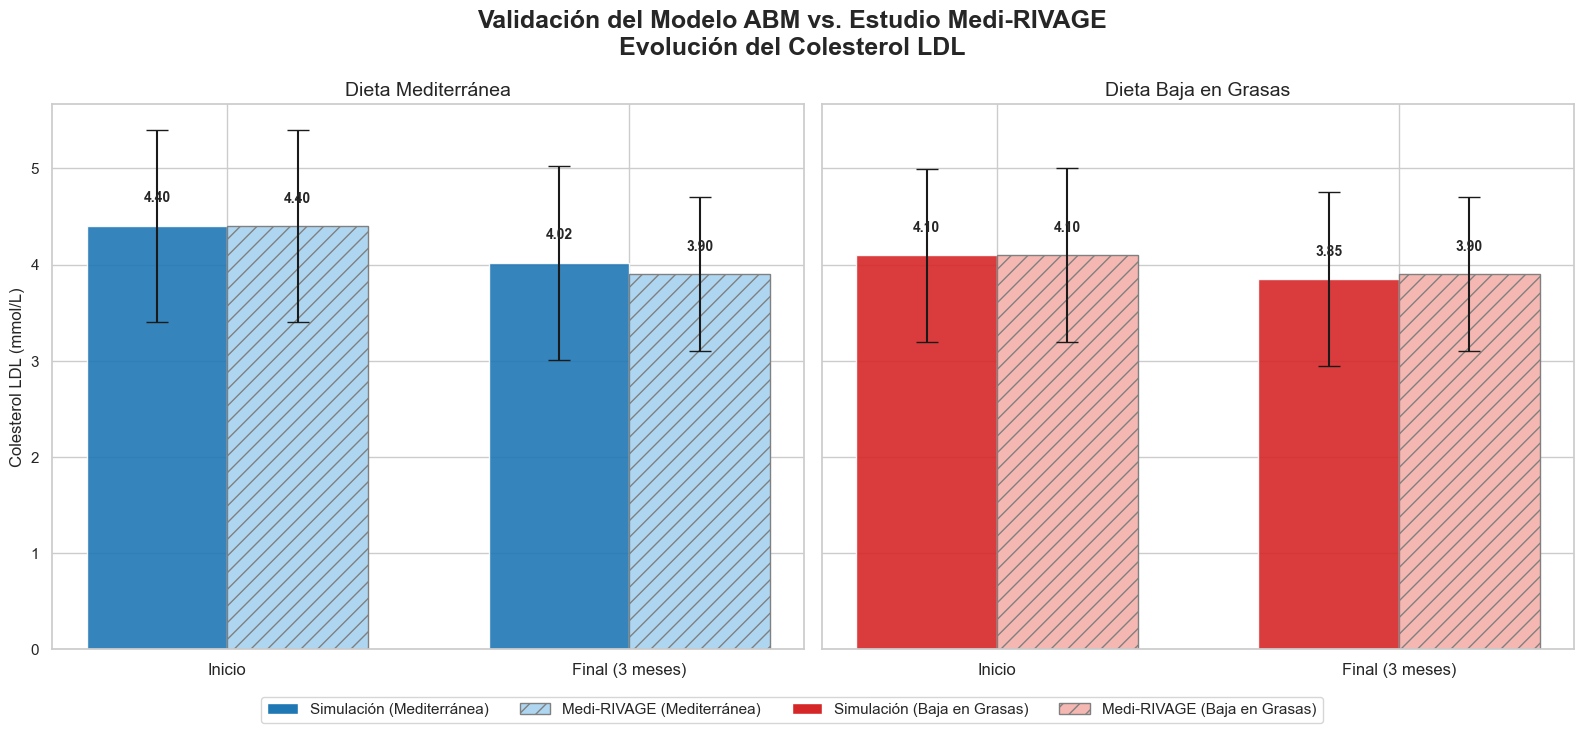

In [3]:
# 1. Datos del estudio Medi-RIVAGE
medi_rivage = {
    'Med_Ini': {'media': 4.4, 'std': 1.0},
    'Med_Fin': {'media': 3.9, 'std': 0.8},
    'LF_Ini': {'media': 4.1, 'std': 0.9},
    'LF_Fin': {'media': 3.9, 'std': 0.8}
}

# 2. Extracción de datos de la simulación
df_inicio = df[df['Step'] == 0]
df_final = df[(df['Step'] == 12) & (df['Estado Actual'] == 'ACTIVO')]

# Agrupar datos para Mediterránea
sim_med = [
    df_inicio[df_inicio['Dieta'] == 'Mediterránea']['Colesterol LDL'].mean(),
    df_final[df_final['Dieta'] == 'Mediterránea']['Colesterol LDL'].mean()
]
sim_med_std = [
    df_inicio[df_inicio['Dieta'] == 'Mediterránea']['Colesterol LDL'].std(),
    df_final[df_final['Dieta'] == 'Mediterránea']['Colesterol LDL'].std()
]

est_med = [medi_rivage['Med_Ini']['media'], medi_rivage['Med_Fin']['media']]
est_med_std = [medi_rivage['Med_Ini']['std'], medi_rivage['Med_Fin']['std']]

# Agrupar datos para Low-Fat
sim_lf = [
    df_inicio[df_inicio['Dieta'] == 'Baja en Grasas']['Colesterol LDL'].mean(),
    df_final[df_final['Dieta'] == 'Baja en Grasas']['Colesterol LDL'].mean()
]
sim_lf_std = [
    df_inicio[df_inicio['Dieta'] == 'Baja en Grasas']['Colesterol LDL'].std(),
    df_final[df_final['Dieta'] == 'Baja en Grasas']['Colesterol LDL'].std()
]

est_lf = [medi_rivage['LF_Ini']['media'], medi_rivage['LF_Fin']['media']]
est_lf_std = [medi_rivage['LF_Ini']['std'], medi_rivage['LF_Fin']['std']]

# 3. Comparamos los resultados en un gráfico de barras agrupadas
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

x = np.arange(2) # Dos momentos: Inicio y Final
ancho_barra = 0.35
etiquetas_x = ['Inicio', 'Final (3 meses)']

# --- COLORES POR DIETA ---
color_sim_med = '#1f77b4' 
color_est_med = '#aed6f1'

color_sim_lf = '#d62728'  
color_est_lf = '#f5b7b1'  

# Comparativa DIETA MEDITERRÁNEA
rects1_sim = ax1.bar(x - ancho_barra/2, sim_med, ancho_barra, yerr=sim_med_std, 
                     capsize=8, color=color_sim_med, alpha=0.9)
rects1_est = ax1.bar(x + ancho_barra/2, est_med, ancho_barra, yerr=est_med_std, 
                     capsize=8, color=color_est_med, edgecolor='gray', hatch='//')
ax1.set_title('Dieta Mediterránea', fontsize=14)
ax1.set_xticks(x)
ax1.set_xticklabels(etiquetas_x, fontsize=12)
ax1.set_ylabel('Colesterol LDL (mmol/L)', fontsize=12)

# Comparativa DIETA BAJA EN GRASAS
rects2_sim = ax2.bar(x - ancho_barra/2, sim_lf, ancho_barra, yerr=sim_lf_std, 
                     capsize=8, color=color_sim_lf, alpha=0.9)
rects2_est = ax2.bar(x + ancho_barra/2, est_lf, ancho_barra, yerr=est_lf_std, 
                     capsize=8, color=color_est_lf, edgecolor='gray', hatch='//')
ax2.set_title('Dieta Baja en Grasas', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(etiquetas_x, fontsize=12)

# Función para etiquetas numéricas
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 15), textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1_sim, ax1)
autolabel(rects1_est, ax1)
autolabel(rects2_sim, ax2)
autolabel(rects2_est, ax2)

# Leyenda
legend_elements = [
    mpatches.Patch(facecolor=color_sim_med, label='Simulación (Mediterránea)'),
    mpatches.Patch(facecolor=color_est_med, edgecolor='gray', hatch='//', label='Medi-RIVAGE (Mediterránea)'),
    mpatches.Patch(facecolor=color_sim_lf, label='Simulación (Baja en Grasas)'),
    mpatches.Patch(facecolor=color_est_lf, edgecolor='gray', hatch='//', label='Medi-RIVAGE (Baja en Grasas)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.05), frameon=True, fontsize=11)

plt.suptitle('Validación del Modelo ABM vs. Estudio Medi-RIVAGE\nEvolución del Colesterol LDL', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### Mean Absolute Percentage Error (MAPE)

Ahora, para cuantificar la precisión del modelo frente a los datos clínicos, calculamos el Error Porcentual Absoluto Medio para cada fase de la intervención. Esta métrica nos indica qué tanto se desvía nuestra simulación de la realidad en términos porcentuales.

La fórmula empleada es:
$$MAPE = \frac{|Valor_{Simulado} - Valor_{Estudio}|}{Valor_{Estudio}} \times 100$$

El objetivo sería conseguir un error relativo inferior al 5%, lo que significaría que hemos conseguido diseñar un modelo altamente preciso.

In [4]:
# 1. Recopilar los valores medios del estudio (extraídos del diccionario anterior)
valores_estudio = [
    medi_rivage['Med_Ini']['media'], 
    medi_rivage['Med_Fin']['media'],
    medi_rivage['LF_Ini']['media'], 
    medi_rivage['LF_Fin']['media']
]

# 2. Recopilar valores medios de nuestra simulación
valores_simulacion = [
    df_inicio[df_inicio['Dieta'] == 'Mediterránea']['Colesterol LDL'].mean(),
    df_final[df_final['Dieta'] == 'Mediterránea']['Colesterol LDL'].mean(),
    df_inicio[df_inicio['Dieta'] == 'Baja en Grasas']['Colesterol LDL'].mean(),
    df_final[df_final['Dieta'] == 'Baja en Grasas']['Colesterol LDL'].mean()
]

# 3. Nombres de las filas
etiquetas_filas = [
    'Dieta Mediterránea (Inicio)', 
    'Dieta Mediterránea (Final - 3 Meses)', 
    'Dieta Baja en Grasas (Inicio)', 
    'Dieta Baja en Grasas (Final - 3 Meses)'
]

# 4. DataFrame con los datos 
tabla_error = pd.DataFrame({
    'Fase / Intervención': etiquetas_filas,
    'Valor Estudio (mmol/L)': valores_estudio,
    'Valor Simulación (mmol/L)': valores_simulacion
})

# Calcular el Error Absoluto y el Error Porcentual Relativo
tabla_error['Error Absoluto'] = np.abs(tabla_error['Valor Simulación (mmol/L)'] - tabla_error['Valor Estudio (mmol/L)'])
tabla_error['Error Relativo (%)'] = (tabla_error['Error Absoluto'] / tabla_error['Valor Estudio (mmol/L)']) * 100
tabla_error['Error Absoluto'] = tabla_error['Error Absoluto'].map('{:.3f}'.format)

# Mostrar la tabla
display(tabla_error)

,Fase / Intervención,Valor Estudio (mmol/L),Valor Simulación (mmol/L),Error Absoluto,Error Relativo (%)
0,Dieta Mediterránea (Inicio),4.40,4.40,0.003,0.06
1,Dieta Mediterránea (Final - 3 Meses),3.90,4.02,0.118,3.04
2,Dieta Baja en Grasas (Inicio),4.10,4.10,0.001,0.03
3,Dieta Baja en Grasas (Final - 3 Meses),3.90,3.85,0.050,1.28


### Validación de la Distribución Poblacional (Análisis KDE)

El objetivo del siguiente análisis es demostrar que la variabilidad interindividual simulada se asemeja a la dispersión clínica real. Esto se debe a que, una media correcta podría estar ocultando una población artificialmente homogénea.

A continuación, empleamos la Estimación de Densidad de Kernel (KDE) para visualizar la distribución final del Colesterol LDL (Semana 12) de los agentes virtuales. Sobre esta distribución, superponemos la **Distribución Normal Teórica** esperada, calculada a partir de la media y la desviación estándar publicadas en el estudio Medi-RIVAGE a los 3 meses.

Un alto grado de solapamiento visual entre ambas curvas indica que el modelo no solo predice la tendencia central, sino también la varianza natural de la población frente a la intervención dietética.

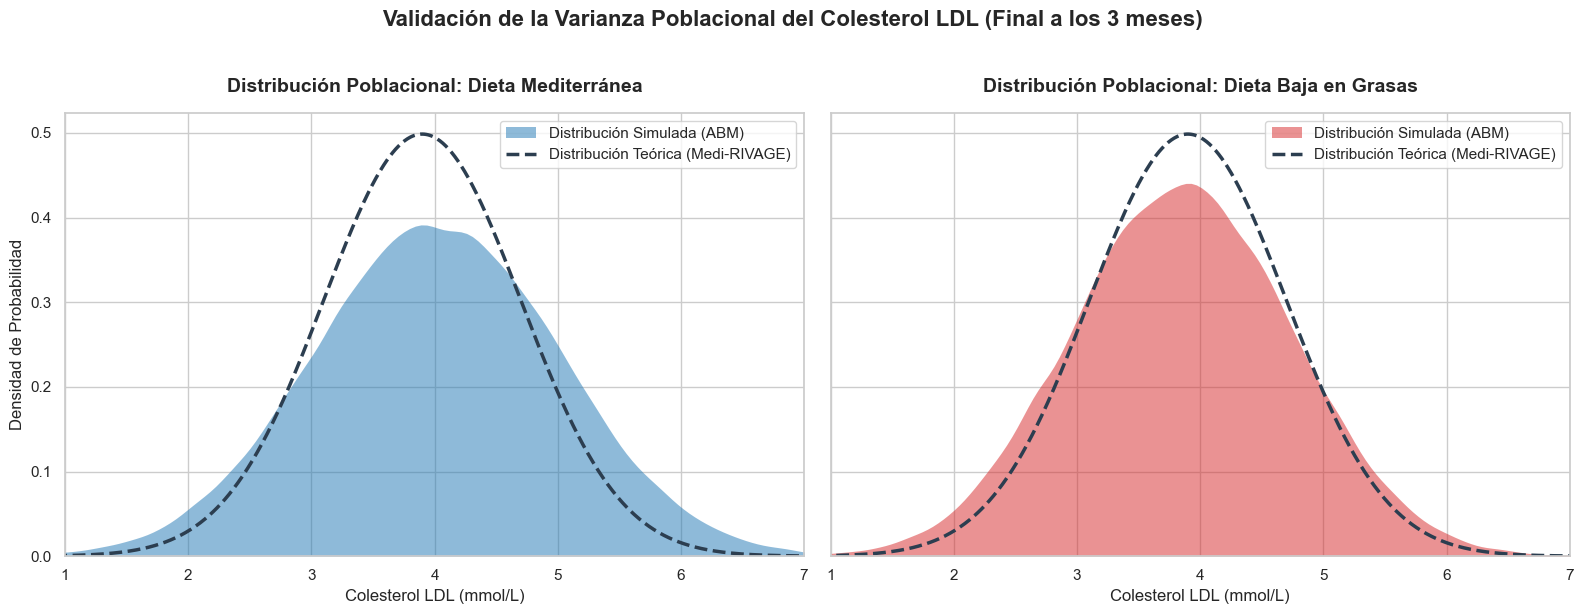

In [5]:
# 1. Definir los parámetros teóricos del estudio a los 3 meses (Media y Desviación Estándar)
mu_estudio_med = medi_rivage['Med_Fin']['media']
std_estudio_med = medi_rivage['Med_Fin']['std']

mu_estudio_lf = medi_rivage['LF_Fin']['media']
std_estudio_lf = medi_rivage['LF_Fin']['std']

# Extraemos la serie de datos completa de todos los pacientes en la semana 12
sim_med_fin = df_final[df_final['Dieta'] == 'Mediterránea']['Colesterol LDL']
sim_lowfat_fin = df_final[df_final['Dieta'] == 'Baja en Grasas']['Colesterol LDL']

# 2. Configurar la figura en dos gráficos
sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
x_axis = np.linspace(0, 8, 1000)

# ==========================================================
# GRÁFICO 1: Dieta Mediterránea
# ==========================================================
# A. Curva de los pacientes simulados (KDE sombreado)
sns.kdeplot(sim_med_fin, ax=ax1, fill=True, color='#1f77b4', alpha=0.5, label='Distribución Simulada (ABM)', linewidth=0)

# B. Campana de Gauss Teórica del Estudio (Línea punteada)
curva_teorica_med = norm.pdf(x_axis, mu_estudio_med, std_estudio_med)
ax1.plot(x_axis, curva_teorica_med, color='#2c3e50', linestyle='--', linewidth=2.5, label='Distribución Teórica (Medi-RIVAGE)')

ax1.set_title('Distribución Poblacional: Dieta Mediterránea', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Colesterol LDL (mmol/L)', fontsize=12)
ax1.set_ylabel('Densidad de Probabilidad', fontsize=12)
ax1.set_xlim(1, 7)
ax1.legend(loc='upper right', frameon=True)

# ==========================================================
# GRÁFICO 2: Dieta Baja en Grasas
# ==========================================================
# A. Curva de los pacientes simulados (KDE sombreado)
sns.kdeplot(sim_lowfat_fin, ax=ax2, fill=True, color='#d62728', alpha=0.5, label='Distribución Simulada (ABM)', linewidth=0)

# B. Campana de Gauss Teórica del Estudio (Línea punteada)
curva_teorica_lf = norm.pdf(x_axis, mu_estudio_lf, std_estudio_lf)
ax2.plot(x_axis, curva_teorica_lf, color='#2c3e50', linestyle='--', linewidth=2.5, label='Distribución Teórica (Medi-RIVAGE)')

ax2.set_title('Distribución Poblacional: Dieta Baja en Grasas', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Colesterol LDL (mmol/L)', fontsize=12)
ax2.set_xlim(1, 7)
ax2.legend(loc='upper right', frameon=True)

# Título y mostrar
plt.suptitle('Validación de la Varianza Poblacional del Colesterol LDL (Final a los 3 meses)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Validación Dietética: Perfil nutricional simulado vs real

Para garantizar que los resultados clínicos (reducción del LDL) se deben a los mismos mecanismos biológicos observados en la realidad, comparamos la ingesta dietética final de nuestros agentes simulados frente a los registros nutricionales del estudio Medi-RIVAGE en una tabla.

In [6]:
df_nutricion = df_final.copy()

# 1. Convertimos los gramos a Kcal y calculamos el % de la energía total para cada agente
df_nutricion['Kcal_Prot'] = df_nutricion['Proteínas'] * 4.0
df_nutricion['Kcal_Carb'] = df_nutricion['Carbohidratos'] * 4.0
df_nutricion['Kcal_Grasa'] = df_nutricion['Grasas Totales'] * 9.0
df_nutricion['Kcal_Sat'] = df_nutricion['Saturadas'] * 9.0
df_nutricion['Kcal_Mono'] = df_nutricion['Monoinsaturadas'] * 9.0
df_nutricion['Kcal_Poli'] = df_nutricion['Poliinsaturadas'] * 9.0

# Calculamos los porcentajes relativos
df_nutricion['% Proteínas'] = (df_nutricion['Kcal_Prot'] / df_nutricion['Calorías']) * 100
df_nutricion['% Carbohidratos'] = (df_nutricion['Kcal_Carb'] / df_nutricion['Calorías']) * 100
df_nutricion['% Grasa Total'] = (df_nutricion['Kcal_Grasa'] / df_nutricion['Calorías']) * 100
df_nutricion['% Grasa Sat'] = (df_nutricion['Kcal_Sat'] / df_nutricion['Calorías']) * 100
df_nutricion['% Grasa Mono'] = (df_nutricion['Kcal_Mono'] / df_nutricion['Calorías']) * 100
df_nutricion['% Grasa Poli'] = (df_nutricion['Kcal_Poli'] / df_nutricion['Calorías']) * 100

# 2. Extraemos las medias agrupadas por Dieta en la Simulación
medias_sim = df_nutricion.groupby('Dieta')[['Calorías', '% Proteínas', '% Carbohidratos', 
                                            '% Grasa Total', '% Grasa Sat', '% Grasa Mono', '% Grasa Poli']].mean()

# 3. Diccionario con los datos empíricos del ESTUDIO MEDI-RIVAGE 
estudio_nutricion = {
    'Mediterránea': {
        'Calorias': 1501.0, '% Proteínas': 19.6, '% Carbohidratos': 45.9, 
        '% Grasa Total': 34.6, '% Grasa Sat': 10.0, '% Grasa Mono': 15.6, '% Grasa Poli': 5.8
    },
    'Baja en Grasas': {
        'Calorias': 1531.0, '% Proteínas': 21.3, '% Carbohidratos': 44.8, 
        '% Grasa Total': 33.9, '% Grasa Sat': 10.3, '% Grasa Mono': 13.4, '% Grasa Poli': 6.3
    }
}

# 4. Construimos la Tabla Cruzada
filas_metricas = ['Energía (Kcal)', 'Proteínas (%)', 'Carbohidratos (%)', 
                  'Grasa Total (%)', 'Grasa Saturada (%)', 'Grasa Monoinsaturada (%)', 'Grasa Poliinsaturada (%)']

columnas_df = ['Med_Simulada', 'Med_Estudio', 'LF_Simulada', 'LF_Estudio']

# Extraemos las métricas
data_tabla = {
    'Métrica Nutricional': filas_metricas,
    
    'Simulación ABM (Med)': [
        medias_sim.loc['Mediterránea', 'Calorías'], medias_sim.loc['Mediterránea', '% Proteínas'],
        medias_sim.loc['Mediterránea', '% Carbohidratos'], medias_sim.loc['Mediterránea', '% Grasa Total'],
        medias_sim.loc['Mediterránea', '% Grasa Sat'], medias_sim.loc['Mediterránea', '% Grasa Mono'],
        medias_sim.loc['Mediterránea', '% Grasa Poli']
    ],
    'Medi-RIVAGE (Med)': list(estudio_nutricion['Mediterránea'].values()),
    
    'Simulación ABM (Low-Fat)': [
        medias_sim.loc['Baja en Grasas', 'Calorías'], medias_sim.loc['Baja en Grasas', '% Proteínas'],
        medias_sim.loc['Baja en Grasas', '% Carbohidratos'], medias_sim.loc['Baja en Grasas', '% Grasa Total'],
        medias_sim.loc['Baja en Grasas', '% Grasa Sat'], medias_sim.loc['Baja en Grasas', '% Grasa Mono'],
        medias_sim.loc['Baja en Grasas', '% Grasa Poli']
    ],
    'Medi-RIVAGE (Low-Fat)': list(estudio_nutricion['Baja en Grasas'].values())
}

df_tabla_cruzada = pd.DataFrame(data_tabla)

# 5. Formateo para visualización (1 decimal)
cols_numericas = ['Simulación ABM (Med)', 'Medi-RIVAGE (Med)', 'Simulación ABM (Low-Fat)', 'Medi-RIVAGE (Low-Fat)']
for col in cols_numericas:
    df_tabla_cruzada[col] = df_tabla_cruzada[col].apply(lambda x: f"{x:.1f}")

# Mostrar la tabla final
display(df_tabla_cruzada)

,Métrica Nutricional,Simulación ABM (Med),Medi-RIVAGE (Med),Simulación ABM (Low-Fat),Medi-RIVAGE (Low-Fat)
0,Energía (Kcal),1565.7,1501.0,1620.0,1531.0
1,Proteínas (%),19.6,19.6,21.4,21.3
2,Carbohidratos (%),45.9,45.9,44.8,44.8
3,Grasa Total (%),34.4,34.6,33.8,33.9
4,Grasa Saturada (%),9.9,10.0,10.3,10.3
5,Grasa Monoinsaturada (%),15.5,15.6,13.4,13.4
6,Grasa Poliinsaturada (%),5.8,5.8,6.3,6.3


### **1. Tasas de participación y abandono de pacientes**

En primer lugar, para comprobar la validez de la simulación, vamos a comprobar que la distribución de pacientes y tasa de abandonos por dieta de los agentes coinciden con los datos reales del estudio.

Para ello, vamos a evaluar dos factores fundamentales promediando los resultados de las 100 simulaciones al finalizar la Semana 12:
1. **Población Inicial:** Verificamos que ambos grupos parten con la muestra de pacientes correcta (102 pacientes para la Dieta Mediterránea y 110 para la Dieta Baja en Grasas).
2. **Tasa de abandono:** Debemos comprobar que la dieta baja en grasas genera una mayor tasa de abandono (≈26%) que la mediterránea (≈14%).

Para ilustrar los resultados, empleamos un **gráfico de barras apiladas**. La base principal de cada barra representa el número de pacientes que lograron finalizar la dieta a los 3 meses, mientras que la sección superior cuantifica el volumen y porcentaje de pacientes que abandonaron la dieta.

In [7]:
# 1. Extraer los datos de la última semana
df_semana_12 = df[df['Step'] == 12]

# 2. Calcular medias de activos y abandonos a lo largo de las 100 simulaciones
conteos = df_semana_12.groupby(['Nº Simulación', 'Dieta', 'Estado Actual']).size().unstack(fill_value=0)
# Sacamos la media de esas 100 simulaciones
media_estados = conteos.groupby('Dieta').mean().round(0).astype(int)
display(media_estados)

# 3. Extraemos los valores para las gráficas
# Dieta mediterránea
activos_med = media_estados.loc['Mediterránea', 'ACTIVO']
abandono_med = media_estados.loc['Mediterránea', 'ABANDONO']
total_med = activos_med + abandono_med
pct_abandono_med = (abandono_med / total_med) * 100

# Dieta baja en grasas
activos_lf = media_estados.loc['Baja en Grasas', 'ACTIVO']
abandono_lf = media_estados.loc['Baja en Grasas', 'ABANDONO']
total_lf = activos_lf + abandono_lf
pct_abandono_lf = (abandono_lf / total_lf) * 100

Estado Actual,ABANDONO,ACTIVO
Dieta,,
Baja en Grasas,29,81
Mediterránea,14,88


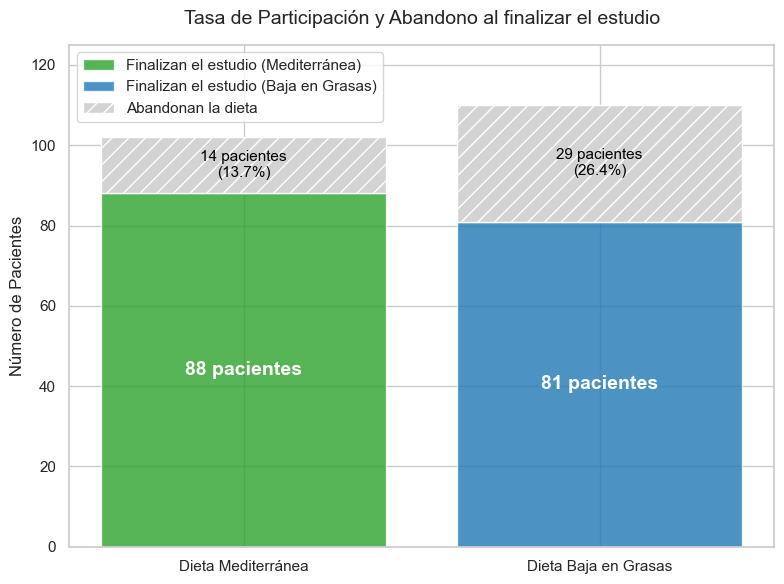

In [8]:
# 4. Dibujar el gráfico de barras apiladas
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))

# Barras base (Pacientes Activos)
ax.bar('Dieta Mediterránea', activos_med, label='Finalizan el estudio (Mediterránea)', color='#2ca02c', alpha=0.8)
ax.bar('Dieta Baja en Grasas', activos_lf, label='Finalizan el estudio (Baja en Grasas)', color='#1f77b4', alpha=0.8)

# Barras superiores (Abandonos) --> Comparten estilo
grupos = ['Dieta Mediterránea', 'Dieta Baja en Grasas']
activos = [activos_med, activos_lf]
abandonos = [abandono_med, abandono_lf]
ax.bar(grupos, abandonos, bottom=activos, label='Abandonan la dieta', color='#d3d3d3', hatch='//')

# Añadir las etiquetas de texto dentro de las barras
ax.text(0, activos_med / 2, f"{activos_med} pacientes", ha='center', va='center', color='white', fontweight='bold', fontsize=14)
ax.text(0, activos_med + (abandono_med / 2), f"{abandono_med} pacientes\n({pct_abandono_med:.1f}%)", ha='center', va='center', color='black', fontsize=11)

ax.text(1, activos_lf / 2, f"{activos_lf} pacientes", ha='center', va='center', color='white', fontweight='bold', fontsize=14)
ax.text(1, activos_lf + (abandono_lf / 2), f"{abandono_lf} pacientes\n({pct_abandono_lf:.1f}%)", ha='center', va='center', color='black', fontsize=11)

# Títulos y etiquetas
plt.title('Tasa de Participación y Abandono al finalizar el estudio', fontsize=14, pad=15)
plt.ylabel('Número de Pacientes', fontsize=12)
plt.ylim(0, 125) # Un poco de margen superior
plt.legend(loc='upper left', frameon=True)

plt.tight_layout()
plt.show()

### **2. Validación de la ingesta nutricional de pacientes**

A continuación, se comprueba que los pacientes han cumplido con la dieta estipulada. El objetivo es analizar el reparto de macronutrientes durante las 12 semanas en aquellos pacientes que han cumplido con la dieta hasta el final.

Para ello, utilizaremos unos gráficos tipo **Pie Chart** en los que se represente la cantidad calórica media ingerida en cada dieta, además del porcentaje de energía que supone eso para cada macronutriente. Para el cálculo se aplican los factores de conversión de Atwater (4 kcal/g para proteínas e hidratos de carbono y 9 kcal/g para las grasas).

In [9]:
# 1. Identificar a los pacientes "ACTIVOS" tras la última semana
# Identificadores únicos combinando su AgentId y Nº Simulación
activos = df_semana_12[df_semana_12['Estado Actual'] == 'ACTIVO'][['Nº Simulación', 'AgentID']]

# 2. Guardar el historial COMPLETO de estos pacientes
# Cruzar datos del df principal con la lista de pacientes activos
df_historial_activos = pd.merge(df, activos, on=['Nº Simulación', 'AgentID'])

# 3. Calcular la media de todas las semanas para cada grupo
cols_nutricion = ['Calorías', 'Proteínas', 'Carbohidratos', 'Saturadas', 'Monoinsaturadas', 'Poliinsaturadas', 'Otras grasas']
medias_nutricion = df_historial_activos.groupby('Dieta')[cols_nutricion].mean()
medias_nutricion

,Calorías,Proteínas,Carbohidratos,Saturadas,Monoinsaturadas,Poliinsaturadas,Otras grasas
Dieta,,,,,,,
Baja en Grasas,1620.15,86.65,181.40,18.49,24.07,11.32,7.02
Mediterránea,1565.66,76.90,179.74,17.31,27.00,10.04,5.61


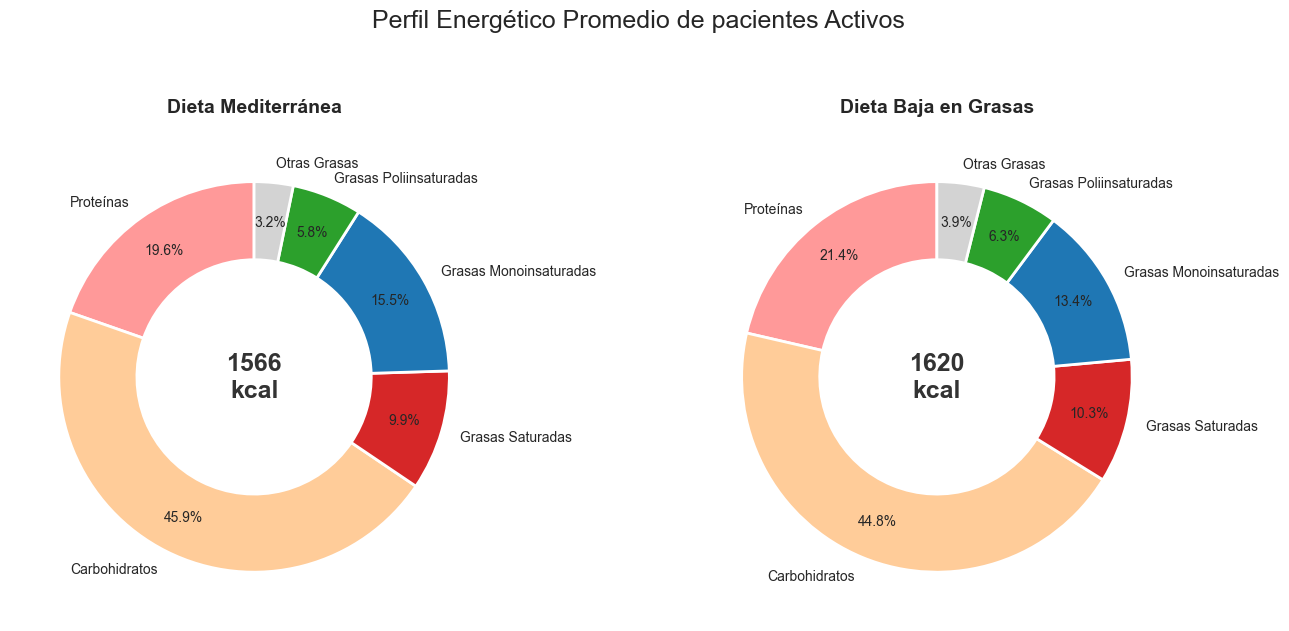

In [10]:
# 4. Dibujar Pie Chart
sns.set_theme(style="white")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
grupos = ['Mediterránea', 'Baja en Grasas']
colores = ['#ff9999', '#ffcc99', '#d62728', '#1f77b4', '#2ca02c', '#d3d3d3']
etiquetas = ['Proteínas', 'Carbohidratos', 'Grasas Saturadas', 'Grasas Monoinsaturadas', 'Grasas Poliinsaturadas', 'Otras Grasas']

for i, grupo in enumerate(grupos):
    # Primero extraemos los gramos
    calorias = medias_nutricion.loc[grupo, 'Calorías']
    prot_g = medias_nutricion.loc[grupo, 'Proteínas']
    carb_g = medias_nutricion.loc[grupo, 'Carbohidratos']
    sat_g = medias_nutricion.loc[grupo, 'Saturadas']
    mono_g = medias_nutricion.loc[grupo, 'Monoinsaturadas']
    poli_g = medias_nutricion.loc[grupo, 'Poliinsaturadas']
    otras_g = medias_nutricion.loc[grupo, 'Otras grasas']
    
    # Convertir gramos a kcal
    g_to_kcal = [prot_g * 4, carb_g * 4, sat_g * 9, mono_g * 9, poli_g * 9, otras_g * 9]
    
    # Dibujar rosco con macronutrientes
    wedges, texts, autotexts = axes[i].pie(
        g_to_kcal, labels=etiquetas, autopct='%1.1f%%',
        startangle=90, colors=colores, pctdistance=0.80,
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2),
        textprops={'fontsize': 10}
    )
    
    # Calorias en el centro
    axes[i].text(0, 0, f"{calorias:.0f}\nkcal", ha='center', va='center', fontsize=18, fontweight='bold', color='#333333')
    axes[i].set_title(f"Dieta {grupo}", fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Perfil Energético Promedio de pacientes Activos', fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

In [11]:
# 1. Identificar registros donde la ingesta fue de 1000 kcal
df_suelo = df[df['Calorías'] == 1000]

# 2. Buscar pacientes que sufrieron esto al menos una vez en su historial
pacientes_suelo = df_suelo.drop_duplicates(subset=['Nº Simulación', 'AgentID', 'Dieta'])

# 3. Contar cuántos pacientes únicos hay afectados por grupo
conteo_suelo = pacientes_suelo.groupby('Dieta').size()

# 4. Contar pacientes totales en cada grupo
pacientes_totales = df[df['Step'] == 0].groupby('Dieta').size()

# 5. DataFrame resumen
tabla_efecto_suelo = pd.DataFrame({
    'Pacientes con Ingesta = 1000 kcal': conteo_suelo,
    'Población Total Simulada': pacientes_totales
})

# 6. Porcentaje representativo
tabla_efecto_suelo['Porcentaje (%)'] = (
    (tabla_efecto_suelo['Pacientes con Ingesta = 1000 kcal'] / tabla_efecto_suelo['Población Total Simulada']) * 100
).round(2)

tabla_efecto_suelo

,Pacientes con Ingesta = 1000 kcal,Población Total Simulada,Porcentaje (%)
Dieta,,,
Baja en Grasas,25364,110000,23.06
Mediterránea,21423,102000,21.00


### **3. Evolución del colesterol LDL a lo largo de la intervención**

En este punto buscamos analizar el impacto que tienen ambas dietas sobre el colesterol LDL de los pacientes a lo largo de las 12 semanas de intervención.

Se espera observar una curva de comportamiento asintótico, donde la reducción es mayor durante las primeras semanas y tiende a estabilizarse una vez que el paciente alcanza un nuevo estado de equilibrio bajo la nueva dieta (últimas semanas).

Para ello, utilizamos un gráfico de líneas con **Intervalos de Confianza (95%)**, calculados a partir de las 100 simulaciones, para garantizar que las diferencias observadas sean robustas y no producto del ruido estocástico del modelo.

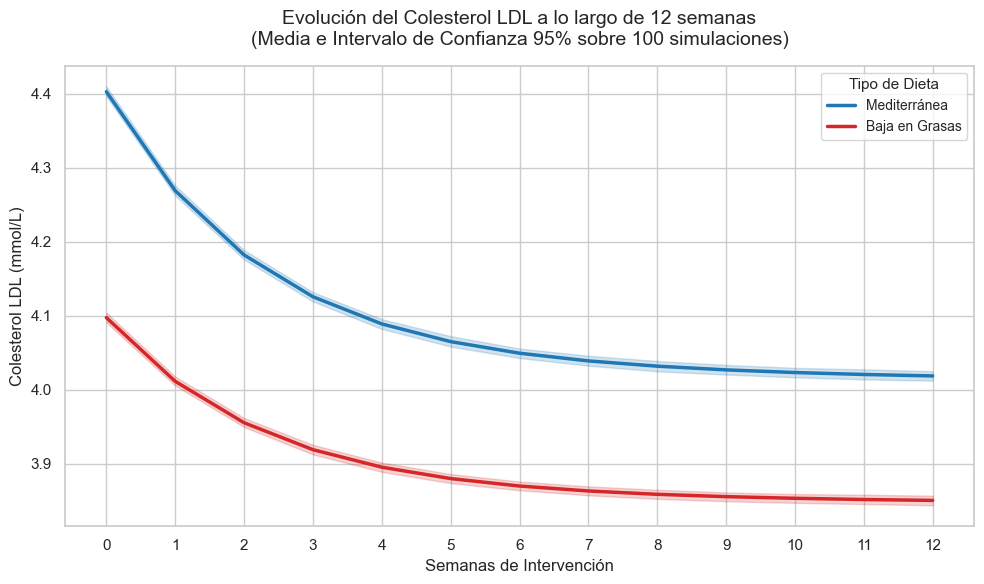

In [12]:
# Dibujar gráfico de líneas con Intervalos de Confianza al 95%
# Configuración del estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Crear gráfica de evolución temporal
grafica = sns.lineplot(
    data=df_historial_activos, 
    x='Step', 
    y='Colesterol LDL', 
    hue='Dieta', 
    palette=['#1f77b4', '#d62728'],
    linewidth=2.5
)

# Título y etiquetas
plt.title('Evolución del Colesterol LDL a lo largo de 12 semanas\n(Media e Intervalo de Confianza 95% sobre 100 simulaciones)', fontsize=14, pad=15)
plt.xlabel('Semanas de Intervención', fontsize=12)
plt.ylabel('Colesterol LDL (mmol/L)', fontsize=12)
plt.xticks(range(0, 13))
plt.legend(title='Tipo de Dieta', title_fontsize='11', fontsize='10')
plt.tight_layout()
plt.show()

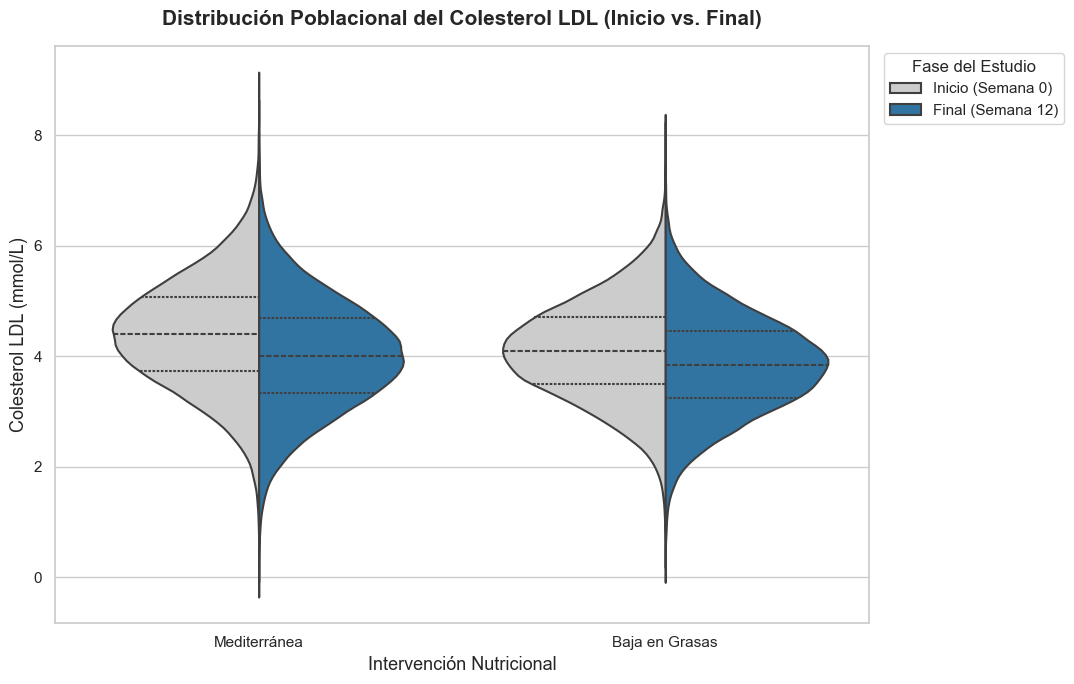

In [13]:
# 1. Quedarnos con los datos iniciales y finales para comparar
df_violines = df_historial_activos[df_historial_activos['Step'].isin([0, 12])].copy()

# 2. Mapear los pasos a etiquetas de texto para la leyenda
df_violines['Momento'] = df_violines['Step'].map({0: 'Inicio (Semana 0)', 12: 'Final (Semana 12)'})

# 3. Dibujar violin plot
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 7))

sns.violinplot(
    data=df_violines,
    x='Dieta',
    y='Colesterol LDL',
    hue='Momento',
    split=True,       
    inner='quartile', 
    palette={'Inicio (Semana 0)': '#cccccc', 'Final (Semana 12)': '#1f77b4'},
    linewidth=1.5
)

# Títulos y etiquetas
plt.title('Distribución Poblacional del Colesterol LDL (Inicio vs. Final)', fontsize=15, pad=15, fontweight='bold')
plt.xlabel('Intervención Nutricional', fontsize=13)
plt.ylabel('Colesterol LDL (mmol/L)', fontsize=13)
plt.legend(title='Fase del Estudio', loc='upper right', bbox_to_anchor=(1.25, 1))
plt.tight_layout()
plt.show()